In [1]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, QFTGate
from qiskit.quantum_info import Statevector

from qiskit_ibm_runtime import SamplerV2
from qiskit_ibm_runtime.fake_provider import FakeHanoiV2, FakeManilaV2, FakeBrisbane
#from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

import numpy as np
from itertools import product

In [2]:
phi = 1/6
mat = [[1.0, 0.0], [0.0, np.exp(2j * np.pi * (phi))]]

Ugate = UnitaryGate(mat, "U").control(1, ctrl_state=1)

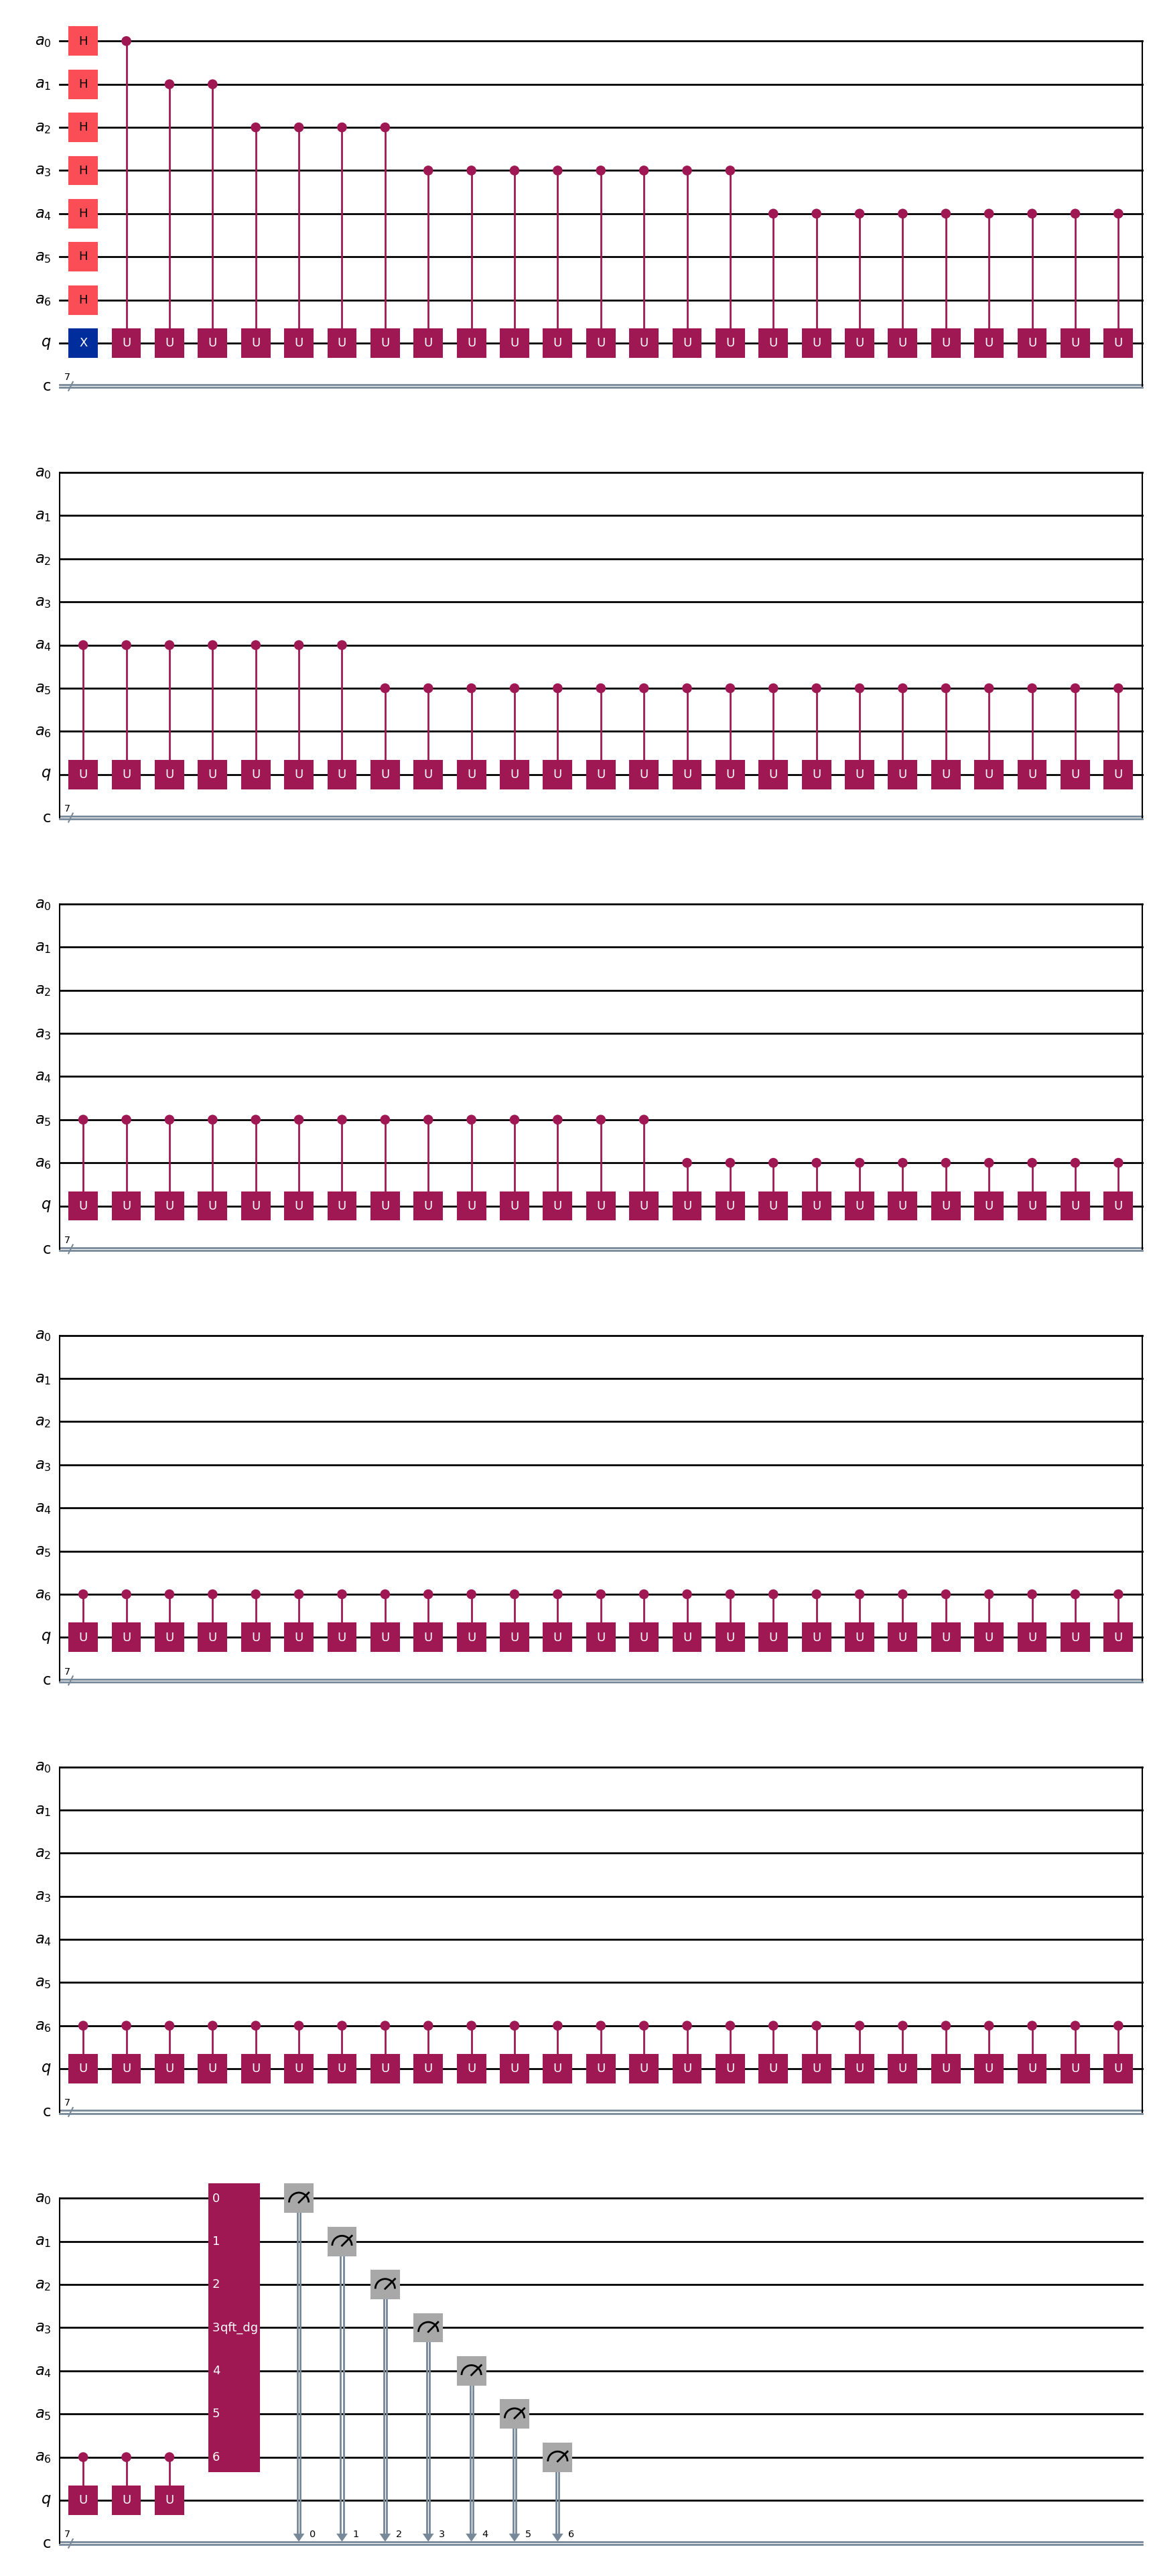

In [8]:
q = QuantumRegister(1, 'q')
a = QuantumRegister(7, 'a')

c = ClassicalRegister(len(a), 'c')

qc = QuantumCircuit(a, q, c)

qc.x(q)

qc.h(a)

for i in range(len(a)):
    for j in range(2 ** (i)):
        qc.append(Ugate, [i, -1])

qc.append(QFTGate(len(a)).inverse(), a)

qc.measure(a, c)

qc.draw('mpl')

In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

backend = FakeBrisbane()

print(backend.name)
print(backend.num_qubits)

from qiskit import transpile

transpiled_circuit = transpile(
    qc,
    backend=backend,
    optimization_level=1
)


from qiskit_aer import AerSimulator

simulator = AerSimulator.from_backend(backend)

job = simulator.run(
    transpiled_circuit,
    shots=1024
)

result = job.result()
counts = result.get_counts()

print(counts)

fake_brisbane
127
{'0010001': 18, '0011001': 20, '1010101': 19, '0011110': 12, '0010101': 125, '1001100': 3, '1110110': 13, '0010110': 70, '1101011': 1, '0010111': 38, '0010010': 25, '0100000': 13, '1110011': 3, '1001111': 4, '0101011': 3, '0110101': 8, '1000000': 3, '1111110': 3, '0000110': 9, '0100110': 4, '0001111': 16, '1110101': 17, '0011011': 5, '0010100': 64, '0101001': 5, '1010110': 15, '0110000': 1, '1000001': 4, '1111101': 6, '0000111': 13, '1100001': 3, '0011101': 17, '1000110': 3, '1111100': 7, '0110111': 3, '0111110': 3, '0100010': 4, '0001000': 7, '0011000': 29, '0101100': 3, '0110100': 9, '1000010': 2, '1010010': 3, '0010000': 19, '1011011': 2, '1100101': 4, '0000101': 16, '1000011': 5, '1111111': 6, '1100110': 3, '0011100': 15, '0010011': 20, '0001001': 6, '1010011': 6, '0111100': 3, '0100100': 4, '0001100': 16, '0100011': 6, '1011010': 3, '0011111': 10, '1010001': 6, '1010000': 2, '0011010': 17, '0111001': 3, '1000111': 5, '1111011': 2, '0101010': 2, '0110110': 11, '11

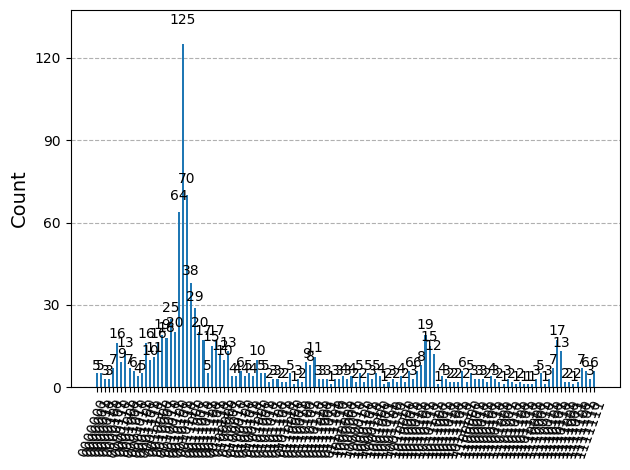

In [10]:
plot_histogram(counts)

In [ ]:
backend = FakeBrisbane()

"""from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.least_busy(simulator=True, operational=True)"""

In [ ]:
# Transpile the ideal circuit to a circuit that can be
# directly executed by the backend
transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw('mpl', style="iqp")

# Run the transpiled circuit using the simulated fake backend
sampler = SamplerV2(backend)
job = sampler.run([transpiled_circuit])
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()
plot_histogram(counts)

In [ ]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

sampler = Sampler(backend)
job = sampler.run([isa_qc], shots = 4096)

In [ ]:
pub_result = job.result()[0]
counts = pub_result.data.c.get_counts()

BasicProviderError: 'Number of qubits 127 is greater than maximum (24) for "basic_simulator".'

In [ ]:
plot_histogram(counts)

In [13]:
def get_qpe_result(counts):
    """
    Extract the most frequent QPE result.

    Parameters
    ----------
    counts : dict
        Qiskit measurement counts, e.g.
        {'0100': 4096}

    Returns
    -------
    state : str
        Most frequent measured bitstring.

    integer_value : int
        Integer represented by the measured bitstring.

    phase : float
        QPE phase = integer_value / 2**n_qubits.

    probability : float
        Probability of obtaining the most frequent state.
    """

    # Most frequently measured state
    state = max(counts, key=counts.get)

    # Number of QPE qubits
    n_qubits = len(state)

    # Binary bitstring -> integer k
    integer_value = int(state, 2)

    # QPE phase
    phase = integer_value / (2 ** n_qubits)

    # Probability of this outcome
    total_shots = sum(counts.values())
    probability = counts[state] / total_shots

    return state, integer_value, phase, probability

state, integer, phase, probability = get_qpe_result(counts)

state, integer, phase, phi

('0010101', 21, 0.1640625, 0.16666666666666666)

In [15]:
error = np.abs(phase - phi) * 100 /phi

error

np.float64(1.5624999999999944)